#Importar datos

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación

In [3]:
total_t1 = tienda['Precio'].sum()
total_t2 = tienda2['Precio'].sum()
total_t3 = tienda3['Precio'].sum()
total_t4 = tienda4['Precio'].sum()

# Crear un DataFrame para visualizar los totales
total_por_tienda = pd.DataFrame({
    'Tienda': ['Tienda 1:', 'Tienda 2:', 'Tienda 3:', 'Tienda 4:'],
    'Total Ventas': [total_t1, total_t2, total_t3, total_t4]
})
print("\nResumen de Venta Total por Tienda:")
print(total_por_tienda.to_string(index=False, float_format='{:,.2f}'.format))



Resumen de Venta Total por Tienda:
   Tienda     Total Ventas
Tienda 1: 1,150,880,400.00
Tienda 2: 1,116,343,500.00
Tienda 3: 1,098,019,600.00
Tienda 4: 1,038,375,700.00


#2. Ventas por categoría

In [4]:
# Lista de los DataFrames de las tiendas y sus nombres
dataframes_tiendas = [tienda, tienda2, tienda3, tienda4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

print("Análisis de ventas por categoría en cada tienda:")
print("=" * 60) # Separador principal

# Iterar sobre cada tienda
for nombre, df_tienda in zip(nombres_tiendas, dataframes_tiendas):
    print(f"\n--- {nombre} ---")

    # Verificar si el DataFrame no está vacío y tiene la columna necesaria
    if not df_tienda.empty and 'Categoría del Producto' in df_tienda.columns:
        # Agrupar por 'Categoría del Producto' y contar las filas (ventas) en cada grupo
        ventas_por_categoria = df_tienda.groupby('Categoría del Producto').size()

        # Verificar si el resultado del groupby no está vacío
        if not ventas_por_categoria.empty:
            # 1. Mostrar la lista completa ordenada de mayor a menor
            ventas_ordenadas = ventas_por_categoria.sort_values(ascending=False)
            print("Ventas por Categoría (ordenadas):")
            print(ventas_ordenadas)
            print("-" * 30) # Separador interno

            # 2. Encontrar y mostrar la categoría más vendida (usando los datos ya calculados)
            categoria_mas_vendida = ventas_por_categoria.idxmax()
            cantidad_ventas = ventas_por_categoria.max()
            print(f"Categoría más vendida: {categoria_mas_vendida} ({cantidad_ventas} ventas)")

        else:
            print("No se encontraron categorías con ventas en esta tienda.")

    else:
        print(f"No se encontraron datos o la columna 'Categoría del Producto' para {nombre}.")

    print("-" * 60) # Separador entre tiendas


Análisis de ventas por categoría en cada tienda:

--- Tienda 1 ---
Ventas por Categoría (ordenadas):
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
dtype: int64
------------------------------
Categoría más vendida: Muebles (465 ventas)
------------------------------------------------------------

--- Tienda 2 ---
Ventas por Categoría (ordenadas):
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
dtype: int64
------------------------------
Categoría más vendida: Muebles (442 ventas)
------------------------------------------------------------

--- Ti

#3. Calificación promedio de la tienda

In [5]:
print("\nCalificación promedio por tienda:")
print("=" * 60) # Separador principal

# Crear un diccionario para almacenar las calificaciones promedio
calificaciones_promedio = {}

# Iterar sobre cada tienda
for nombre, df_tienda in zip(nombres_tiendas, dataframes_tiendas):
    print(f"\n--- {nombre} ---")

    # Verificar si el DataFrame no está vacío y tiene la columna 'Calificación'
    if not df_tienda.empty and 'Calificación' in df_tienda.columns:
        # Calcular la media de la columna 'Calificación'
        calificacion_media = df_tienda['Calificación'].mean()

        # Guardar en el diccionario (opcional, pero útil para resumen)
        calificaciones_promedio[nombre] = calificacion_media

        # Imprimir la calificación promedio para esta tienda, formateada a 2 decimales
        print(f"Calificación promedio: {calificacion_media:.2f}")

    else:
        print(f"No se encontraron datos o la columna 'Calificación' para {nombre}.")
        calificaciones_promedio[nombre] = None # Opcional: indicar que no hay dato

    print("-" * 60) # Separador entre tiendas



Calificación promedio por tienda:

--- Tienda 1 ---
Calificación promedio: 3.98
------------------------------------------------------------

--- Tienda 2 ---
Calificación promedio: 4.04
------------------------------------------------------------

--- Tienda 3 ---
Calificación promedio: 4.05
------------------------------------------------------------

--- Tienda 4 ---
Calificación promedio: 4.00
------------------------------------------------------------


#4. Productos más y menos vendidos

In [6]:
print("\nProductos más y menos vendidos por tienda:")
print("=" * 60) # Separador principal

# Iterar sobre cada tienda
for nombre, df_tienda in zip(nombres_tiendas, dataframes_tiendas):
    print(f"\n--- {nombre} ---")

    # Verificar si el DataFrame no está vacío y tiene la columna 'Producto'
    if not df_tienda.empty and 'Producto' in df_tienda.columns:
        # Agrupar por 'Producto' y contar las veces que aparece cada uno (cantidad vendida)
        ventas_por_producto = df_tienda.groupby('Producto').size()

        # Verificar si el resultado del groupby no está vacío
        if not ventas_por_producto.empty:
            # Encontrar el producto con el máximo número de ventas
            producto_mas_vendido = ventas_por_producto.idxmax()
            cantidad_mas_vendido = ventas_por_producto.max()
            print(f"Producto más vendido: {producto_mas_vendido} ({cantidad_mas_vendido} unidades)")

            # Encontrar el producto con el mínimo número de ventas
            producto_menos_vendido = ventas_por_producto.idxmin()
            cantidad_menos_vendido = ventas_por_producto.min()
            print(f"Producto menos vendido: {producto_menos_vendido} ({cantidad_menos_vendido} unidades)")

        else:
            print("No se encontraron datos de ventas de productos en esta tienda.")

    else:
        print(f"No se encontraron datos o la columna 'Producto' para {nombre}.")

    print("-" * 60) # Separador entre tiendas


Productos más y menos vendidos por tienda:

--- Tienda 1 ---
Producto más vendido: Armario (60 unidades)
Producto menos vendido: Auriculares con micrófono (33 unidades)
------------------------------------------------------------

--- Tienda 2 ---
Producto más vendido: Iniciando en programación (65 unidades)
Producto menos vendido: Juego de mesa (32 unidades)
------------------------------------------------------------

--- Tienda 3 ---
Producto más vendido: Kit de bancas (57 unidades)
Producto menos vendido: Bloques de construcción (35 unidades)
------------------------------------------------------------

--- Tienda 4 ---
Producto más vendido: Cama box (62 unidades)
Producto menos vendido: Guitarra eléctrica (33 unidades)
------------------------------------------------------------


# 5. Envío promedio por tienda

In [7]:
print("\nCosto de envío promedio por tienda:")
print("=" * 60) # Separador principal

# Crear un diccionario para almacenar los costos de envío promedio (opcional)
envios_promedio = {}

# Iterar sobre cada tienda
for nombre, df_tienda in zip(nombres_tiendas, dataframes_tiendas):
    print(f"\n--- {nombre} ---")

    # Verificar si el DataFrame no está vacío y tiene la columna 'Costo de envío'
    if not df_tienda.empty and 'Costo de envío' in df_tienda.columns:
        # Calcular la media de la columna 'Costo de envío'
        costo_envio_medio = df_tienda['Costo de envío'].mean()

        # Guardar en el diccionario (opcional)
        envios_promedio[nombre] = costo_envio_medio

        # Imprimir el costo de envío promedio, formateado como moneda
        print(f"Costo de envío promedio: {costo_envio_medio:,.2f}") # Formato con separador de miles y 2 decimales

    else:
        print(f"No se encontraron datos o la columna 'Costo de envío' para {nombre}.")
        envios_promedio[nombre] = None # Opcional: indicar que no hay dato

    print("-" * 60) # Separador entre tiendas


Costo de envío promedio por tienda:

--- Tienda 1 ---
Costo de envío promedio: 26,018.61
------------------------------------------------------------

--- Tienda 2 ---
Costo de envío promedio: 25,216.24
------------------------------------------------------------

--- Tienda 3 ---
Costo de envío promedio: 24,805.68
------------------------------------------------------------

--- Tienda 4 ---
Costo de envío promedio: 23,459.46
------------------------------------------------------------


# 6. Gráficos

In [14]:
# --- Configuración de estilo  ---
sns.set_theme(style="dark")
plt.rcParams['figure.figsize'] = (20, 6) # Tamaño predeterminado para las figuras



--- Gráfico 1: Ventas Totales por Tienda ---


/tmp/ipykernel_60008/1044900003.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_ventas = sns.barplot(x='Tienda', y='Total Ventas', data=total_por_tienda, palette='PuRd')


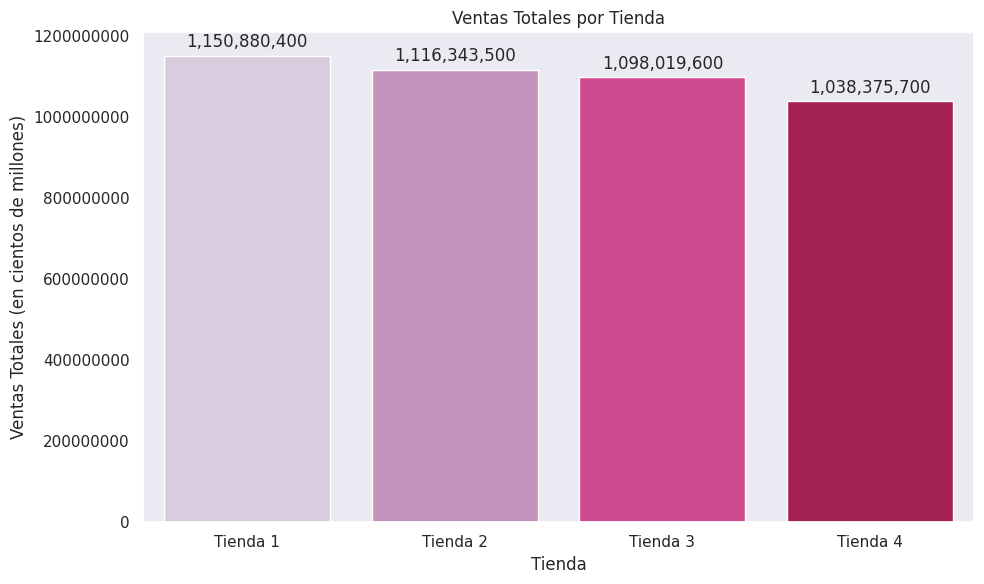


--- Gráfico 2: Calificación Promedio por Tienda ---


/tmp/ipykernel_60008/1044900003.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot_calif = sns.barplot(x=calificaciones_promedio_series.index, y=calificaciones_promedio_series.values, palette='RdPu')


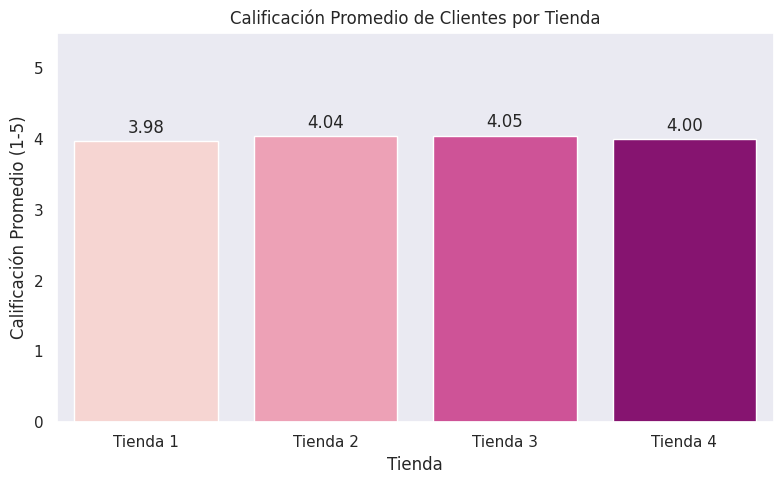


--- Gráfico 3: Relación Precio vs. Costo de Envío ---


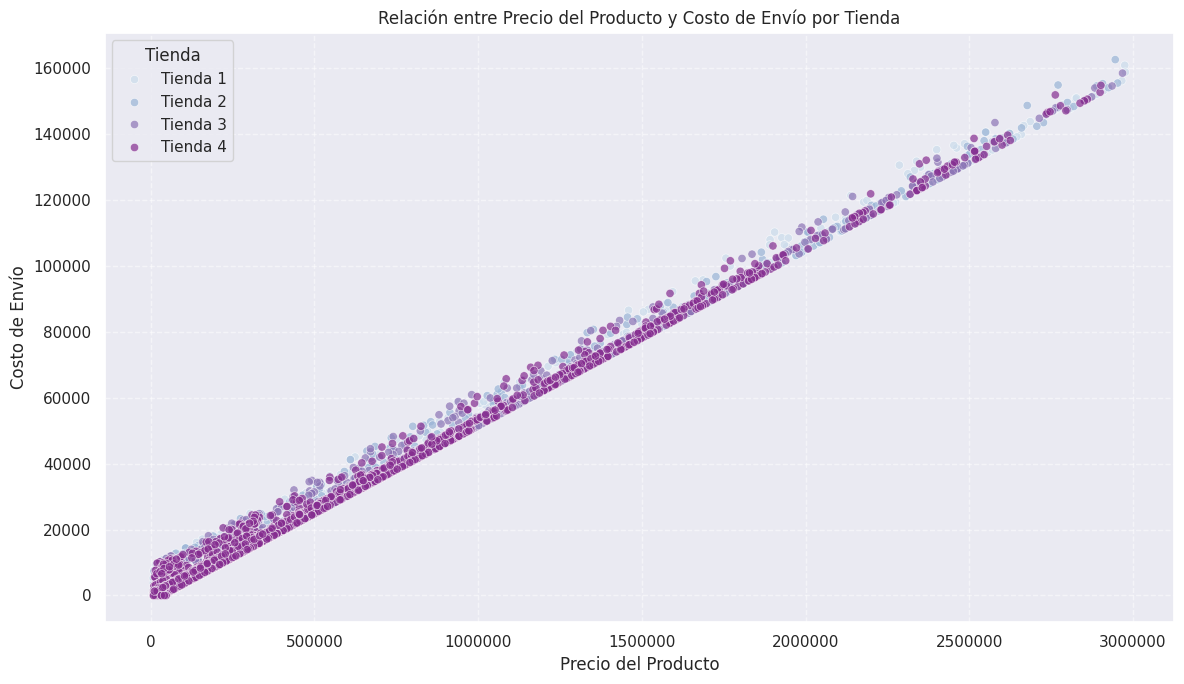

In [19]:
# --- Preparación de datos para gráficos (si es necesario) ---

# 1. Datos para Ventas Totales
total_por_tienda['Tienda'] = total_por_tienda['Tienda'].str.replace(':', '', regex=False)


# 2. Datos para Calificaciones Promedio
# Convertir a Series para facilitar el gráfico
calificaciones_promedio_series = pd.Series(calificaciones_promedio).dropna() # dropna por si alguna tienda no tenía datos

# 3. Datos combinados para Scatter Plot (Precio vs Costo Envío)
# Necesitamos un único DataFrame con todos los datos y una columna indicando la tienda

dfs_con_nombre = []
for nombre, df in zip(nombres_tiendas, dataframes_tiendas):
    df_copy = df.copy() # Trabajar con una copia para no modificar los originales
    df_copy['Nombre Tienda'] = nombre
    dfs_con_nombre.append(df_copy)

df_combinado = pd.concat(dfs_con_nombre, ignore_index=True)

# --- Gráfico 1: Comparación de Ventas Totales por Tienda (Gráfico de Barras) ---
print("\n--- Gráfico 1: Ventas Totales por Tienda ---")
plt.figure(figsize=(10, 6))
barplot_ventas = sns.barplot(x='Tienda', y='Total Ventas', data=total_por_tienda, palette='PuRd')
plt.title('Ventas Totales por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Ventas Totales (en cientos de millones)')

plt.ticklabel_format(style='plain', axis='y')
# Añadir etiquetas de valor sobre las barras
for container in barplot_ventas.containers:
    barplot_ventas.bar_label(container, fmt='{:,.0f}', label_type='edge', padding=3)
plt.tight_layout()
plt.show()


# --- Gráfico 2: Comparación de Calificación Promedio por Tienda (Gráfico de Barras) ---
print("\n--- Gráfico 2: Calificación Promedio por Tienda ---")
plt.figure(figsize=(8, 5))
barplot_calif = sns.barplot(x=calificaciones_promedio_series.index, y=calificaciones_promedio_series.values, palette='RdPu')
plt.title('Calificación Promedio de Clientes por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Calificación Promedio (1-5)')
plt.ylim(0, 5.5)
# Añadir etiquetas de valor sobre las barras
for container in barplot_calif.containers:
    barplot_calif.bar_label(container, fmt='{:.2f}', label_type='edge', padding=3)
plt.tight_layout()
plt.show()


# --- Gráfico 3: Relación entre Precio y Costo de Envío (Gráfico de Dispersión) ---
print("\n--- Gráfico 3: Relación Precio vs. Costo de Envío ---")
plt.figure(figsize=(12, 7))
scatterplot = sns.scatterplot(data=df_combinado, x='Precio', y='Costo de envío', hue='Nombre Tienda', alpha=0.7, palette='BuPu')
plt.title('Relación entre Precio del Producto y Costo de Envío por Tienda')
plt.xlabel('Precio del Producto')
plt.ylabel('Costo de Envío')
plt.ticklabel_format(style='plain', axis='both') # Evitar notación científica
plt.legend(title='Tienda')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



#7. Análisis de resultados


#Informe del Análisis de tiendas
Mediante este informe se pretende analizar el desempeño de cuatro tiendas (Tienda 1,2,3 y 4). El objetivo es generar una recomendación fundamentada sobre la mejor tienda para enfocar los esfuerzos de venta, tomando en cuenta el análisis de datos efectuado a dicha base de datos.

# Desarrollo
## 1. Ingresos Totales por Tienda

Dicho calculo da como resultado la siguiente informacion

*   **Tienda 1:** 1,150,880,400.00
*   **Tienda 2:** 1,116,343,500.00
*   **Tienda 3:** 1,098,019,600.00
*   **Tienda 4:** 1,038,375,700.00

## 2. Ventas por categoria

La cantidad de ventas por categoria en cada tienda es el siguiente:

1. **Categoría Más Vendida (Consistentemente): Muebles** es la categoría con mayor número de ventas en todas las tiendas.

    - Tienda 1: Muebles (465 ventas)
    - Tienda 2: Muebles (442 ventas)
    - Tienda 3: Muebles (499 ventas)
   - Tienda 4: Muebles (480 ventas)

2. **Categorías Menos Vendidas (Variable):** Las categorías con menos ventas varían, pero frecuentemente incluyen "Artículos para el hogar" e "Instrumentos musicales".

   - Tienda 1: Artículos para el hogar (171 ventas)
   - Tienda 2: Artículos para el hogar (181 ventas)
   - Tienda 3: Instrumentos musicales / Artículos para el hogar (177 ventas cada una)
   - Tienda 4: Instrumentos musicales (170 ventas)

## 3. Calificación promedio de clientes

La calificación promedio de cada tienda, en una escala 1-5, es la siguiente:

- **Tienda 1:** 3.98
- **Tienda 2:** 4.04
- **Tienda 3:** 4.05
- **Tienda 4:** 4.00

## 4. Productos más y menos vendidos (por unidad)

Haciendo el análisis, se tiene el siguiente resultado:

- **Tienda 1:**
  - **Más Vendido:** Armario con 60 unidades vendidas
  - **Menos Vendido:** Auriculares con micrófono con 33 unidades vendidas
- **Tienda 2:**
  - **Más Vendido:** Iniciando en programación con 65 unidades vendidas
  - **Menos Vendido:** Juego de mesa con 32 unidades vendidas
- **Tienda 3:**
  - **Más Vendido:** Kit de bancas con 57 unidades vendidas
  - **Menos Vendido:** Bloques de construcción con 35 unidades vendidas
- **Tienda 4:**
  - **Más Vendido:** Cama box con 62 unidades vendidas
  - **Menos Vendido:** Guitarra eléctrica con 33 unidades vendidas

  ##  Costo de envío promedio

  El costo promedio de envío por transaccion es la siguiente:

- **Tienda 1:** 26,018.61
- **Tienda 2:** 25,216.24
- **Tienda 3:** 24,805.68
- **Tienda 4:** 23,459.46

## Conclusion

Evaluando la informacion y los distintos análisis realizados en este documento, se puede observar que:

- La Tienda 1 es la que genera mayor ingreso.
- Hay mayor demanda de muebles en todas las tiendas.
- La tienda 3 cuenta con mayor volumen en ventas.
- La Tienda 3 es la que cuenta con mayor puntuacion, seguida por poco por la Tienda 2.
- La Tienda 1 es la que tiene un costo promedio de envio mas elevado comparado con las demas tiendas.
- La tienda que genera menor ingreso es la 4.


## Recomendación Final

Siendo los resultados relativamente parejos, segun lo evaluado la tienda que debe vender es la Tienda 4 a pesar de ser la segunda con mayor venta en la categoria muebles, sobretodo es la que genera menor ingreso, su puntuación cliente es la penultuma. Al igual que las otras tiendas, se especializa en productos electrónicos y mantiene el mismo porcentaje de costos de envío, por lo que su venta no afectaría la diversificación o el modelo de negocio.

